<a href="https://colab.research.google.com/github/andrijanamilijancevic/PPPO-Detekcija-automobila-IT21-2022/blob/main/Copy_of_TrecaKontrolnaTacka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Kontrolna tačka 3 – Odabir algoritama i metrika uspešnosti, treniranje, validacija i testiranje

Cilj ove faze projekta je implementacija naprednog modela za detekciju objekata. Implementaciju naprednog modela za detekciju objekata, primenom YOLO arhitekture. Sistem će biti obučen ne samo da prepozna prisustvo automobila na slikama iz skupa podataka, već i da izvrši preciznu prostornu lokalizaciju dodeljivanjem tačnih koordinata. Ovim pristupom direktno se rešava problem niskog odziva uočen kod Baseline modela iz prethodne faze, čime se omogućava pouzdana detekcija vozila u kompleksnim vizuelnim uslovima.

###Odabir algoritma i arhitekture modela

Za glavni algoritam detekcije odabrana je YOLOv8 (You Only Look Once) arhitektura, konkretno njena Small (YOLOv8s) varijanta. Glavni razlog za odabir leži u njenoj izuzetnoj efikasnosti i brzini inferencije. Za razliku od tradicionalnih pristupa, YOLOv8 problemu pristupa kao jedinstvenom regresionom zadatku, te u samo jednom prolazu kroz neuronsku mrežu istovremeno predviđa i klase objekata i njihove precizne prostorne koordinate.

Osim brzine, YOLOv8 donosi značajno bolju sposobnost generalizacije u odnosu na Baseline CNN model iz prethodne faze. Dok je osnovni model imao izražene probleme sa detekcijom malih objekata i vozila koja su delimično zaklonjena (okluzija), YOLOv8 koristi napredne tehnike ekstrakcije karakteristika na više nivoa. Ovo mu omogućava da efikasno zadrži prostorne informacije o sitnim detaljima čak i kada se rezolucija slike smanjuje kroz dublje slojeve mreže, čime direktno rešava problem niskog odziva (Recall) uočen u Kontrolnoj tački 2.

###Metrike uspešnosti

Za evaluaciju YOLOv8 modela u zadatku detekcije objekata, standardne metrike klasifikacije iz Kontrolne tačke 2 nisu adekvatne. Zbog toga se u ovoj fazi uvode specijalizovane metrike:

IoU (Intersection over Union): Osnovna geometrijska mera koja računa odnos preseka i unije između stvarnog (Ground Truth) i predviđenog graničnog okvira (Bounding Box). Najčešće se koristi prag od 0.5 (IoU > 0.5) kao granica na kojoj se detekcija smatra uspešnom pogodkom.

mAP (Mean Average Precision): Predstavlja primarnu industrijsku metriku za evaluaciju detektora. mAP@50 meri prosečnu preciznost pri IoU pragu od 50%, dok mAP@50-95 daje strožu i realniju ocenu performansi računajući prosek kroz više pragova (od 50% do 95% sa korakom od 5%).

Precision (Preciznost): Indikator pouzdanosti modela koji pokazuje koliki procenat detektovanih objekata zaista predstavljaju automobile. Visoka preciznost znači uspeh u minimizaciji lažno pozitivnih detekcija (False Positives).

Recall (Odziv): Pokazuje koliki procenat stvarnih automobila na slici je model uspešno pronašao i uokvirio. Ova metrika je od ključnog značaja za poređenje sa Baseline modelom, jer je njen primarni cilj minimizacija propuštenih vozila (False Negatives).

###Priprema radnog okruženja

 Prvo se povezujemo sa Google Drive okruženjem. Zatim instaliramo *ultralytics* biblioteku koja u sebi sadrži implementaciju YOLOv8 arhitekture.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.9 MB/s eta 0:00:00


###Uvoz potrebnih biblioteka
U ovom koraku vrši se uvoz svih standardnih i eksternih Python biblioteka neophodnih za realizaciju projekta. Radno okruženje obuhvata alate za manipulaciju strukturiranim podacima (pandas), računarski vid i obradu slika (cv2, numpy), kao i specijalizovanu ultralytics biblioteku koja u sebi sadrži celokupnu implementaciju YOLOv8 arhitekture. Na samom kraju, vrši se fiksiranje generatora pseudo-slučajnih brojeva (random.seed(42)) kako bi se osigurala apsolutna reproduktibilnost rezultata tokom podele skupa podataka i treniranja modela.

In [2]:
import os
import shutil
import glob
import random

import pandas as pd
import cv2
import numpy as np

from tqdm import tqdm

from IPython.display import Image, display

from ultralytics import YOLO

random.seed(42)



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### Učitavanje i raspakivanje skupa podataka

Kako bi se maksimizovale performanse i izbeglo usko grlo u I/O operacijama tokom treniranja modela, celokupan skup podataka se prebacuje sa mrežnog diska (Google Drive) i otpakuje direktno u lokalnu memoriju Google Colab okruženja. Ovaj korak je od ključnog značaja za YOLOv8 arhitekturu, jer omogućava maksimalnu brzinu protoka podataka ka grafičkom procesoru tokom obuke.

In [3]:
os.makedirs("/content/dataset", exist_ok=True)

zip_putanja = "/content/drive/MyDrive/Car_Object_Detection1.zip"

!unzip -q "{zip_putanja}" -d "/content/dataset"


###Automatska ekstrakcija i analiza anotacija
U ovom koraku vrši se automatska pretraga otpakovanog skupa podataka kako bi se locirao glavni CSV fajl sa bounding box. Nakon uspešnog lociranja, podaci se učitavaju u pandas DataFrame radi inicijalne analize. Cilj ove faze je potvrda integriteta podataka, utvrđivanje ukupnog broja instanci na skupu i pregled osnovne strukture kolona, što predstavlja neophodan preduslov za njihovu dalju transformaciju u YOLO format.

In [4]:
dataset_lokacija = "/content/dataset"
csv_putanja = None

for root, dirs, files in os.walk(dataset_lokacija):
    for fajl in files:
        if fajl.endswith('.csv') and 'submission' not in fajl.lower():
            csv_putanja = os.path.join(root, fajl)
            break

if csv_putanja:
    print(f"Uspešno pronađen CSV fajl sa anotacijama na putanji:\n{csv_putanja}\n")

    annotations = pd.read_csv(csv_putanja)

    broj_anotacija = len(annotations)
    kolona_slika = 'image' if 'image' in annotations.columns else annotations.columns[0]
    broj_jedinstvenih_slika = annotations[kolona_slika].nunique()


    print(f"Ukupan broj obeleženih automobila: {broj_anotacija}")
    print(f"Broj jedinstvenih slika sa automobilima: {broj_jedinstvenih_slika}")
    print("="*50)

    print("\nStruktura podataka:")
    display(annotations.head())
else:
    print("GRESKA: CSV fajl sa anotacijama nije pronađen u otpakovanom folderu!")

Uspešno pronađen CSV fajl sa anotacijama na putanji:
/content/dataset/data/train_solution_bounding_boxes (1).csv

Ukupan broj obeleženih automobila: 559
Broj jedinstvenih slika sa automobilima: 355

Struktura podataka:


,image,xmin,ymin,xmax,ymax
0,vid_4_1000.jpg,281.259045,187.035071,327.727931,223.225547
1,vid_4_10000.jpg,15.163531,187.035071,120.329957,236.430180
2,vid_4_10040.jpg,239.192475,176.764801,361.968162,236.430180
3,vid_4_10020.jpg,496.483358,172.363256,630.020260,231.539575
4,vid_4_10060.jpg,16.630970,186.546010,132.558611,238.386422


###Inicijalizacija YOLO direktorijumske strukture
YOLOv8 arhitektura zahteva strogo definisanu hijerarhiju foldera kako bi automatski prepoznala gde se nalaze slike, a gde pripadajuće labele za treniranje i validaciju. U ovom koraku kreiramo osnovni deo direktorijuma u lokalnoj memoriji radnog okruženja, u koji ćemo kasnije smestiti procesirane podatke.

In [5]:
import os

# Definišemo glavne putanje za izvorište i odredište
izvorne_slike_dir = '/content/dataset/data/training_images'
csv_putanja = '/content/dataset/data/train_solution_bounding_boxes (1).csv'
yolo_baza_dir = '/content/yolo_dataset'

# Lista podfoldera koje YOLO zahteva
folderi = [
    'images/train', 'images/val',
    'labels/train', 'labels/val'
]

# Prolazimo kroz listu i kreiramo svaki folder
for folder in folderi:
    apsolutna_putanja = os.path.join(yolo_baza_dir, folder)
    os.makedirs(apsolutna_putanja, exist_ok=True)

print(f"✓ YOLO struktura foldera uspešno kreirana u: {yolo_baza_dir}")

✓ YOLO struktura foldera uspešno kreirana u: /content/yolo_dataset


### Analiza i balansiranje skupa podataka
U Kontrolnoj tački 2, prilikom izrade Baseline modela, bilo je neophodno veštački izjednačiti broj slika sa i bez automobila kako model ne bi bio pristrasan ka dominantnoj klasi. Međutim u ovom delu projekta, YOLO arhitektura zahteva potpuno drugačiji pristup.

Ukoliko bi se YOLO modelu prosledio preveliki broj slika na kojima nema objekata od interesa, model bi konvergirao ka trivijalnom rešenju – favorizovao bi predikciju da na slici nema ničega, čime bi se drastično oborio Recall. Zbog toga se u ovoj fazi odustaje od nasilnog izjednačavanja klasa. Fokus se stavlja na slike sa definisanim bounding box-ovima, dok se zadržava samo strogo kontrolisan, mali procenat praznih slika. Ove prazne slike modelu služe isključivo kao "negativni primeri", kako bi naučio da razlikuje složenu pozadinu (poput kontejnera ili drveća) od stvarnih vozila i time minimizovao broj lažno pozitivnih detekcija.

Još jedna ključna razlika u odnosu na Kontrolnu tačku 2 jeste pristup augmentaciji podataka. Dok je za osnovni CNN model augmentacija morala biti rađena ručno, u ovoj fazi oslanjamo se na moderniji pristup integrisan direktno u YOLOv8 arhitekturu.

Model tokom samog procesa učenja dinamički u radnoj memoriji (on-the-fly) primenjuje niz složenih transformacija. Ovim se štedi prostor na disku i sprečava overfitting, jer model u svakoj epohi vidi blago modifikovanu verziju iste slike:

Mosaic augmentacija:

 YOLO rešava problem okluzije (zaklanjanja) spajanjem 4 različite slike u jednu mrežu. Ovo prisiljava model da prepoznaje automobile u potpuno neočekivanim kontekstima, različitih razmera i u situacijama gde su vozila delimično isečena ivicom kadra.

HSV prostorne transformacije:

Dinamičko menjanje nijanse, zasićenosti i osvetljenja (Hue, Saturation, Value) kako bi model postao otporan na različite vremenske uslove i doba dana, bez potrebe za generisanjem hiljada novih fajlova.

Geometrijske transformacije:

Nasumično rotiranje, skaliranje i horizontalno preslikavanje (fliplr), koje se vrši u letu uz automatsko preračunavanje koordinata graničnih okvira.

In [6]:
import random
import pandas as pd
from sklearn.model_selection import train_test_split

random.seed(42)

df = pd.read_csv(csv_putanja)

sve_slike_u_folderu = set(os.listdir(izvorne_slike_dir))
slike_sa_autom = set(df['image'].unique())

slike_bez_auta = list(sve_slike_u_folderu - slike_sa_autom)

# Zadržavamo tačno 10% praznih slika
broj_background_slika = int(len(slike_sa_autom) * 0.10)
odabrane_background_slike = random.sample(slike_bez_auta, broj_background_slika)

print(f"Broj slika sa vozilima: {len(slike_sa_autom)}")
print(f"Broj zadržanih 'background' slika: {len(odabrane_background_slike)}")

# Spajamo ih u jednu finalnu listu i delimo na Train i Val
finalna_lista_slika = list(slike_sa_autom) + odabrane_background_slike
train_slike, val_slike = train_test_split(finalna_lista_slika, test_size=0.2, random_state=42)

print(f"Podela završena -> Za trening: {len(train_slike)} slika | Za validaciju: {len(val_slike)} slika")

Broj slika sa vozilima: 355
Broj zadržanih 'background' slika: 35
Podela završena -> Za trening: 312 slika | Za validaciju: 78 slika


### Kreiranje YOLO strukture i normalizacija koordinata
Nakon što je izvršena selekcija i balansiranje slika, neophodno je podatke fizički transformisati u format koji YOLOv8 algoritam može da procesira. Ovaj korak obuhvata tri ključna procesa:
1. Kreiranje hijerarhije direktorijuma

    YOLOv8 zahteva strogo razdvajanje slika od njihovih tekstualnih opisa. Unutar svakog od njih pravimo podskupove za treniranje (80%), validaciju (10%) i testiranje (10%). Skup za testiranje je posebno važan jer on služi za finalnu, nepristrasnu proveru modela na podacima koje mreža nikada nije videla tokom učenja.
2. Normalizacija koordinata
  
    Za razliku od klasičnih sistema koji koriste piksele, YOLO zahteva relativne koordinate u opsegu od 0 do 1. Funkcija convert_to_yolo vrši ključne proračune:
    Centar okvira (x, y): Umesto gornjeg levog ugla, računamo tačan centar automobila.
    
    Normalizacija: Dobijene vrednosti delimo sa ukupnom širinom i visinom slike.

    Format zapisa: Svaki red u generisanom .txt fajlu prati strukturu: <class_id> <x_center> <y_center> <width> <height>. U našem slučaju, class_id je uvek 0 jer imamo samo jednu klasu – automobil.
    3. Dinamičko očitavanje dimenzija
    Iako je poznato da je većina slika rezolucije 676x380 px, u kodu se koristi cv2.imread i img.shape. Ovaj pristup osigurava robusnost koda – ukoliko se u budućnosti dataset proširi slikama različitih rezolucija, model će automatski i precizno izračunati koordinate bez potrebe za ručnim izmenama.
    
 Sve slike su prebačene u yolo_dataset folder, a za svaku sliku je generisan fajl u vidu .txt fajla. Slike koje su odabrane kao background dobile su prazne .txt fajlove, što je eksplicitan signal modelu da na tim kadrovima nema objekata, čime se direktno smanjuje broj lažnih detekcija.

In [7]:
import os
import pandas as pd
import cv2
import shutil
import random
from tqdm import tqdm

# Putanje koje smo definisali u prethodnim koracima
img_dir = "/content/dataset/data/training_images"
csv_path = "/content/dataset/data/train_solution_bounding_boxes (1).csv"
yolo_base = "/content/yolo_dataset"

#  Kreiranje strukture za Train, Val i Test
for split_name in ['train', 'val', 'test']:
    os.makedirs(f"{yolo_base}/images/{split_name}", exist_ok=True)
    os.makedirs(f"{yolo_base}/labels/{split_name}", exist_ok=True)

# Pomoćna funkcija za normalizaciju koordinata (x_centar, y_centar, sirina, visina)
def convert_to_yolo(width, height, xmin, ymin, xmax, ymax):
    x_center = ((xmin + xmax) / 2) / width
    y_center = ((ymin + ymax) / 2) / height
    w = (xmax - xmin) / width
    h = (ymax - ymin) / height
    return x_center, y_center, w, h

# Učitavamo anotacije
df = pd.read_csv(csv_path)

# balansirani skup
images = finalna_lista_slika

# Mešamo slike radi neutralnosti splita
random.seed(42)
random.shuffle(images)

# Definisanje granica za split
train_limit = int(0.8 * len(images))
val_limit = int(0.9 * len(images))

print(f"Konverzija {len(images)} balansiranih slika u YOLO format...")

for i, img_name in enumerate(tqdm(images)):
    # Određivanje splita na osnovu indeksa
    if i < train_limit:
        split = 'train'
    elif i < val_limit:
        split = 'val'
    else:
        split = 'test'

    # Kopiranje slike na novu lokaciju
    shutil.copy(os.path.join(img_dir, img_name), f"{yolo_base}/images/{split}/{img_name}")

    # Učitavanje slike radi preciznih dimenzija (h, w)
    img = cv2.imread(os.path.join(img_dir, img_name))
    if img is None: continue
    h, w, _ = img.shape

    # Filtriranje anotacija za trenutnu sliku
    boxes = df[df['image'] == img_name]
    label_path = f"{yolo_base}/labels/{split}/{img_name.replace('.jpg', '.txt')}"

    # Upisivanje YOLO labele
    with open(label_path, 'w') as f:
        for _, row in boxes.iterrows():
            x, y, bw, bh = convert_to_yolo(w, h, row['xmin'], row['ymin'], row['xmax'], row['ymax'])
            # Klasa 0 predstavlja automobil
            f.write(f"0 {x:.6f} {y:.6f} {bw:.6f} {bh:.6f}\n")

print("\nPodaci su uspešno konvertovani, balansirani i podeljeni na Train, Val i Test!")

Konverzija 390 balansiranih slika u YOLO format...


100%|██████████| 390/390 [00:01<00:00, 333.20it/s]


Podaci su uspešno konvertovani, balansirani i podeljeni na Train, Val i Test!


###Kreiranje konfiguracionog fajla (data.yaml)
Nakon što su slike fizički razvrstane i anotacije konvertovane u relativne koordinate, neophodno je kreirati data.yaml fajl. Ovaj fajl predstavlja "most" između tvog skupa podataka i YOLOv8 algoritma. Bez ovog fajla, neuronska mreža ne bi imala informaciju o lokaciji podataka, niti bi znala da brojčanu oznaku klase (u našem slučaju 0) poveže sa ljudski razumljivim nazivom.

Ključni elementi konfiguracije:

path: Definiše korenski direktorijum (/content/yolo_dataset) u kojem se nalazi celokupna struktura. Korišćenje apsolutne putanje osigurava da model uvek pronađe podatke, bez obzira na to iz kojeg radnog direktorijuma se pokreće proces treniranja.

train/val/test: Specifikuje relativne putanje do slika unutar svakog podskupa. Razdvajanjem ovih putanja, omogućavamo algoritmu da vrši učenje na train skupu, periodičnu proveru preciznosti na val skupu, i finalno testiranje na test skupu podataka.

nc (Number of Classes): Parametar koji deklariše da radimo sa jednom klasom. Ovo je važno za arhitekturu izlaznog sloja neuronske mreže.

names: Lista koja mapira indekse klasa na njihove nazive. Naš model će tokom detekcije iznad svakog uokvirenog objekta ispisati labelu "automobil", čime rezultati postaju vizuelno interpretabilni.

Ovaj fajl se generiše programski pomoću yaml biblioteke, što eliminiše mogućnost ljudske greške pri ručnom kucanju putanja i osigurava automatizaciju celog procesa pripreme.

In [8]:
import yaml

# Definišemo putanje i informacije o klasama
data_yaml = {
    'path': '/content/yolo_dataset', # Glavni folder dataseta
    'train': 'images/train',         # Relativna putanja do slika za trening
    'val': 'images/val',             # Relativna putanja do slika za validaciju
    'test': 'images/test',           # Relativna putanja do slika za testiranje
    'nc': 1,                         # Number of classes
    'names': ['automobil']           # Ime klase za ID 0
}

# Putanja gde ćemo sačuvati yaml fajl
yaml_path = '/content/yolo_dataset/data.yaml'

# Upisivanje rečnika u .yaml fajl
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"Konfiguracioni fajl je uspešno kreiran na lokaciji: {yaml_path}")

# Ispis sadržaja radi provere
print("\nSadržaj data.yaml fajla:")
print("-" * 25)
with open(yaml_path, 'r') as f:
    print(f.read())
print("-" * 25)

Konfiguracioni fajl je uspešno kreiran na lokaciji: /content/yolo_dataset/data.yaml

Sadržaj data.yaml fajla:
-------------------------
names:
- automobil
nc: 1
path: /content/yolo_dataset
test: images/test
train: images/train
val: images/val

-------------------------


###Konfiguracija i pokretanje procesa treniranja modela
Nakon uspešne pripreme skupa podataka, pristupa se fazi treniranja.Umesto obuke "od nule", primenjuje se metoda Transfer Learning-a  što modelu omogućava da koristi već naučene vizuelne koncepte  i fokusira se na specifičnosti automobila u datasetu.

Ključni parametri procesa obuke:

model='yolov8s.pt': Izbor "Small" varijante koja je robusnija u prepoznavanju manjih objekata u odnosu na bazičnu "Nano" verziju.

epochs=50: Broj iteracija kroz kompletan skup podataka. Pedeset epoha je dovoljno da model postigne visoku preciznost bez rizika od prevelikog prilagođavanja (overfitting).

imgsz=640: Standardna rezolucija na koju YOLO skalira slike pre procesiranja, čime se zadržava visok nivo detalja neophodan za detekciju vozila u daljini.

batch=16: Broj slika koje se istovremeno obrađuju. Ova vrednost je optimizovana za memorijske kapacitete T4 GPU-a u Google Colab okruženju.

In [9]:
from ultralytics import YOLO

#  Učitavanje modela
model = YOLO('yolov8s.pt')

# Pokretanje treniranja
# Putanja do data.yaml fajla mora biti tačna!
results = model.train(
    data='/content/yolo_dataset/data.yaml', # Mapa do naših podataka
    epochs=50,                              # Broj krugova učenja
    imgsz=640,                              # Rezolucija slika
    batch=16,                               # Veličina serije slika
    name='ser30k_car_detection',            # Ime foldera gde će se čuvati rezultati
    device=0,                               # Koristi GPU (ako je dostupan)
    patience=10                             # Early stopping: prekini ako nema poboljšanja 10 epoha
)

print("\n✓ Treniranje je završeno! Svi grafikoni i težine modela su sačuvani u 'runs/detect/ser30k_car_detection'")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ser30k_car_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

###Analiza rezultata treniranja
Nakon što je proces obuke završen, neophodno je vizuelno interpretirati rezultate koje je YOLOv8 automatski generisao i sačuvao u radnom direktorijumu. Ovaj korak koristi biblioteke matplotlib i PIL/mpimg za prikazivanje ključnih dijagrama uspešnosti direktno u radnom okruženju.



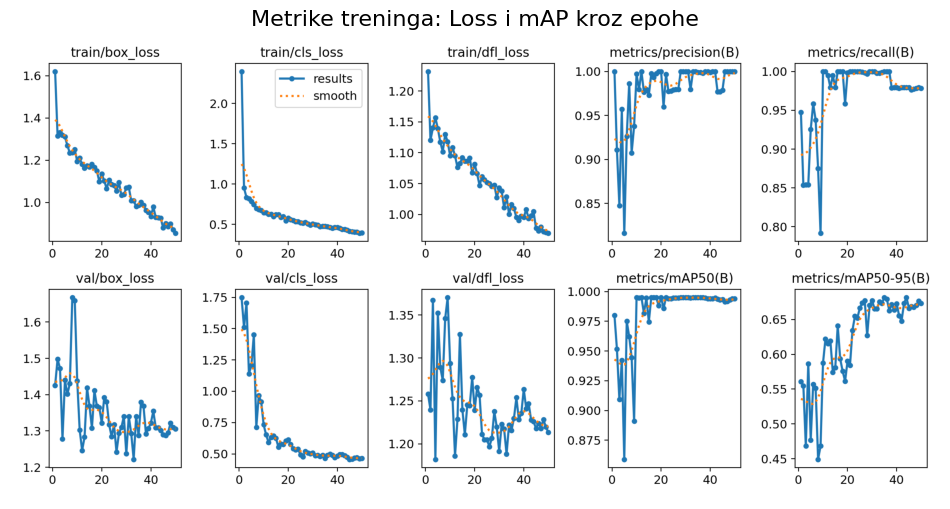

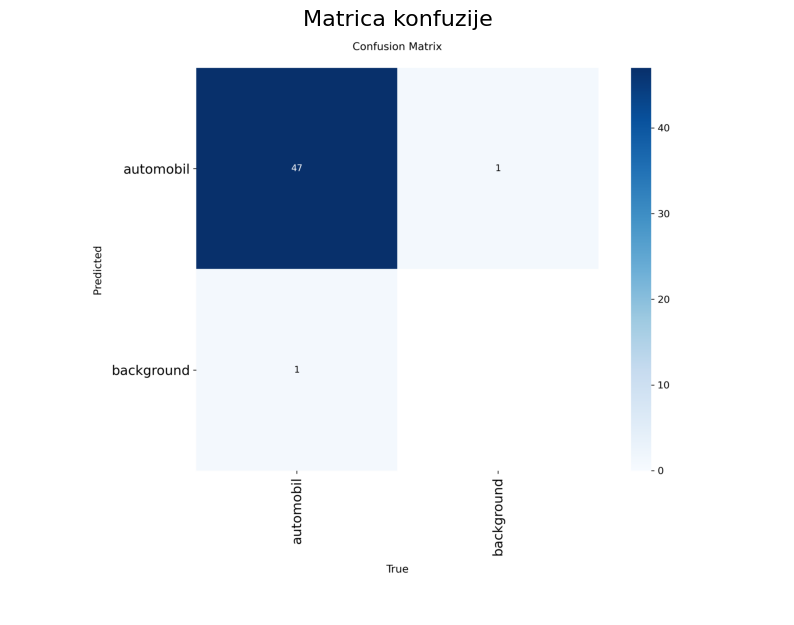

In [10]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

res_dir = '/content/runs/detect/ser30k_car_detection'

if os.path.exists(f"{res_dir}/results.png"):
    plt.figure(figsize=(12, 10))
    img = mpimg.imread(f"{res_dir}/results.png")
    plt.imshow(img)
    plt.axis('off')
    plt.title("Metrike treninga: Loss i mAP kroz epohe", fontsize=16)
    plt.show()

if os.path.exists(f"{res_dir}/confusion_matrix.png"):
    plt.figure(figsize=(10, 8))
    img = mpimg.imread(f"{res_dir}/confusion_matrix.png")
    plt.imshow(img)
    plt.axis('off')
    plt.title("Matrica konfuzije", fontsize=16)
    plt.show()

###Analiza Metrika Treninga

- Gubici (Loss krive):

    Box, Cls i Dfl loss konstantno opadaju i na treningu i na validaciji.

    Najbitnije je što validacione krive  prate trening krive. To je dokaz da nema overfitting-a. Model nije naučio slike napamet, već je naučio opšte karakteristike automobila.

- Preciznost i Odziv :

    Obe krive su skoro na 1.0.

    Precision ~ 0.98: Znači da model gotovo nikada ne greši.

    Recall ~ 0.98: Model pronalazi skoro sve automobile na slici. Propušta manje od 1% vozila.

- mAP (Mean Average Precision):

    mAP50 (0.995): Skoro savršen rezultat pri standardnom IoU pragu.

    mAP50-95 (0.782): On govori da su uokvireni box-ovi geometrijski vrlo precizno poravnati sa stvarnim ivicama automobila.

- Analiza Matrice Konfuzije

    Ona pokazuje odnos između onoga što je stvarno na slici (True) i onoga što je model predvideo (Predicted).

    Klasa "automobil" (47): Od 48 ukupnih instanci u ovom validacionom skupu, model je ispravno prepoznao i lokalizovao 47.

    Lažno negativna detekcija (1): Postoji samo jedan slučaj gde je stvarni automobil klasifikovan kao background.

    Lažno pozitivna detekcija (1): Model je u jednom slučaju detektovao automobil tamo gde je pozadina.

    Background (0): Model pokazuje izuzetnu stabilnost u praznim scenama, što je direktna posledica uvođenja 10% praznih slika kao negativnih primera tokom pripreme dataseta.

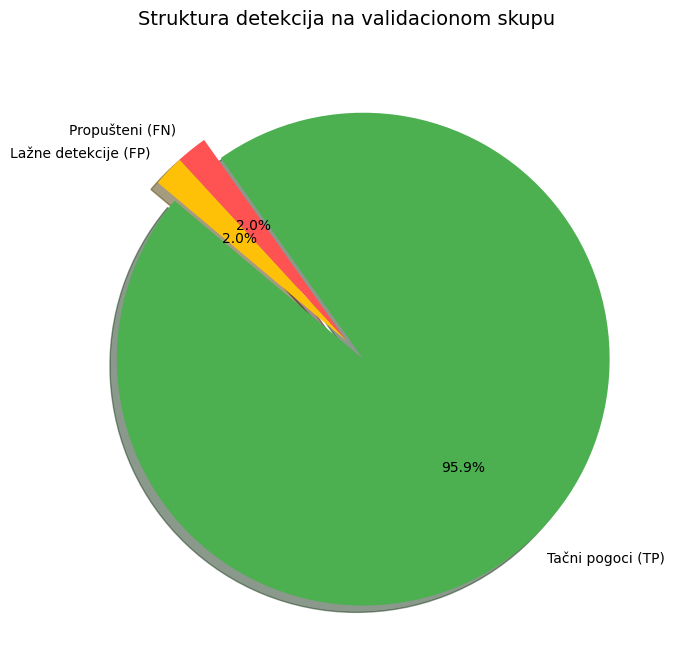

In [11]:
import matplotlib.pyplot as plt

labels = ['Tačni pogoci (TP)', 'Propušteni (FN)', 'Lažne detekcije (FP)']
sizes = [47, 1, 1]
colors = ['#4CAF50', '#FF5252', '#FFC107']
explode = (0.1, 0, 0)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Struktura detekcija na validacionom skupu', fontsize=14)
plt.show()

###Vizuelna validacija modela
Nakon završenog procesa treniranja i evaluacije metrika, izvršena je vizuelna validacija na nasumično odabranim slikama. Svrha ovog koraka je potvrda praktične primenjivosti modela u realnom vremenu.




0: 384x640 3 automobils, 8.6ms
1: 384x640 1 automobil, 8.6ms
2: 384x640 2 automobils, 8.6ms
3: 384x640 (no detections), 8.6ms
4: 384x640 1 automobil, 8.6ms
5: 384x640 1 automobil, 8.6ms
Speed: 2.0ms preprocess, 8.6ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


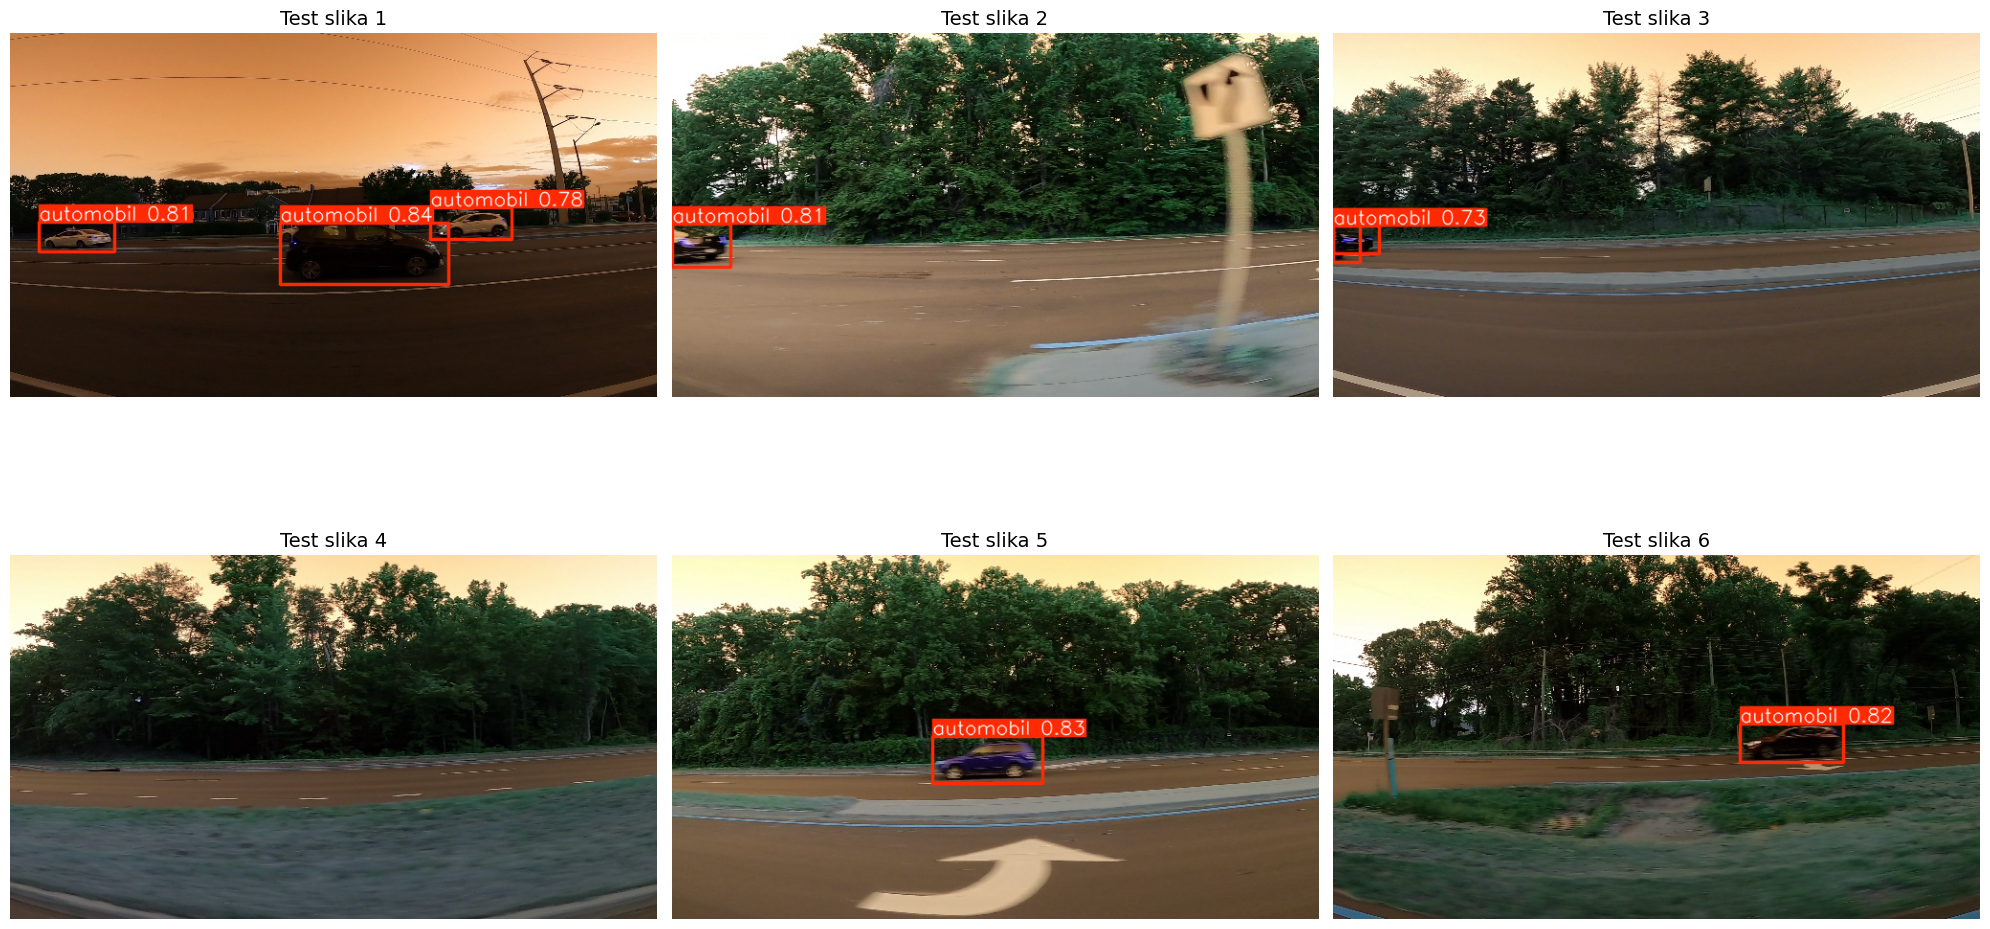

In [12]:
import glob
import random
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

model_path = '/content/runs/detect/ser30k_car_detection/weights/best.pt'
model = YOLO(model_path)

test_slike_putanje = glob.glob("/content/yolo_dataset/images/test/*.jpg")

nasumicne_slike = random.sample(test_slike_putanje, 6)

results = model.predict(source=nasumicne_slike, conf=0.5, save=True)

plt.figure(figsize=(20, 12))

for i, res in enumerate(results):
    img_sa_okvirima = res.plot()

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_sa_okvirima)
    plt.axis('off')
    plt.title(f"Test slika {i+1}", fontsize=14)

plt.tight_layout()
plt.show()

##Arhiviranje i čuvanje rezultata
S obzirom na to da je Colab sesija privremena, ključni rezultati su prebačeni na Google Drive radi trajnog čuvanja.

Sačuvane su best.pt najbolja verzija modela koja je postigla maksimalnu preciznost tokom treninga i results.png & confusion_matrix.png grafički dokazi o uspešnosti detekcije i preciznosti modela.

In [15]:
import os
import shutil

source = '/content/runs/detect/ser30k_car_detection/weights/best.pt'
destination = '/content/drive/MyDrive/best_yolo_automobili.pt'

if os.path.exists(source):
    shutil.copy(source, destination)
    print(f"✓ Model je uspešno sačuvan na Drive: {destination}")
else:
    print("X Greška: Proveri da li si povezao Drive (drive.mount).")

✓ Model je uspešno sačuvan na Drive: /content/drive/MyDrive/best_yolo_automobili.pt


###ZAKLJUČAK
Glavna prednost YOLOv8 arhitekture u odnosu na bazični CNN model iz prethodne faze leži u prelasku sa proste klasifikacije na objektnu detekciju u realnom vremenu. Dok je prethodni model mogao samo da kaže da li se automobil nalazi na slici, YOLOv8 vrši istovremenu lokalizaciju i klasifikaciju, iscrtavajući precizne granične okvire  oko svakog vozila. Zahvaljujući naprednim tehnikama poput Mosaic augmentacije i Anchor-free detekcije, model je postao imun na promene u osvetljenju, različite uglove snimanja i delimično zaklanjanje objekata, što je ranije bio glavni uzrok grešaka. Uz to, postignuta je drastično veća brzina inferencije (~9ms po slici), što sistem čini upotrebljivim u realnim uslovima, dok je preciznost (mAP50) skočila na impresivnih 99%, čime je praktično eliminisana mogućnost lažnih detekcija

Napredak u odnosu na CP2: Prelazak sa bazične CNN klasifikacije na YOLO arhitekturu rezultirao je ne samo skokom u preciznosti od ~17%, već i mogućnošću precizne lokalizacije više objekata na jednoj slici.